<a href="https://colab.research.google.com/github/Andrian0s/ML4NLP1-2025-Tutorial-Notebooks/blob/main/tutorials_notebooks_in_class_2025/Qdrant_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ****Python Qdrant client****

In [1]:
pip install qdrant-client==1.16.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.5/378.5 kB 13.7 MB/s eta 0:00:00


In [ ]:
from qdrant_client import QdrantClient

# In memory: Do not save data in  disk
client = QdrantClient(":memory:")
# NOTE: You can save data in disk by client = QdrantClient(path="path/to/db")

print("Qdrant client initialized successfully.")

Qdrant client initialized successfully.


# ****Dummy example****

## Create a collection

To create a vector index, we specify the vector dimensionality and the metric for computing similarity.

In [ ]:
from qdrant_client.models import Distance, VectorParams

client.create_collection(
    collection_name="dummy_collection",
    vectors_config=VectorParams(size=2, distance=Distance.COSINE),
)

True

##Insert vectors into the collection

In [ ]:
from qdrant_client.models import PointStruct

# Our vectors are the unit circle's intersections with the positive coordinate axes
vectors = [
    [1, 0],
    [0, 1],
]

points = []
i = 0
for vector, name in zip(vectors, ["x_axis", "y_axis"]):
  points.append(
      PointStruct(
          id=i,
          vector=vector,
          payload={"name": name}
      )
  )
  i += 1

client.upload_points(
  collection_name="dummy_collection",
  points=points
)

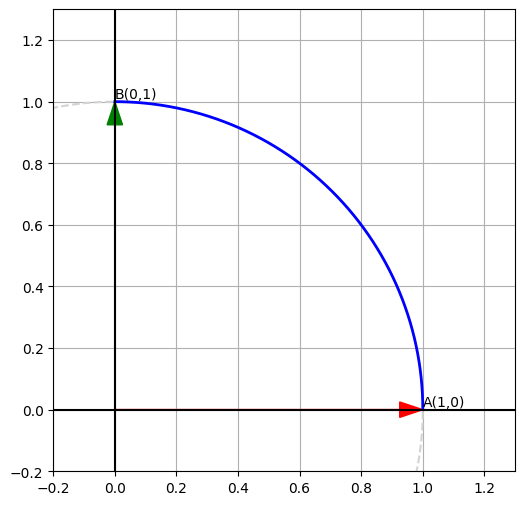

In [ ]:
from IPython.display import Image
Image('1.png')

We have indexed a set of vectors in the collection, and we can query them!

##Search for similar vectors

In [ ]:
import numpy as np

query_vector = [np.sqrt(3)/2, 1/2]
hits = client.query_points(
    collection_name="dummy_collection",
    query=query_vector,
    limit=1  # Return "closest" point
)

## Question: What vector should be returned, and what should be its score?

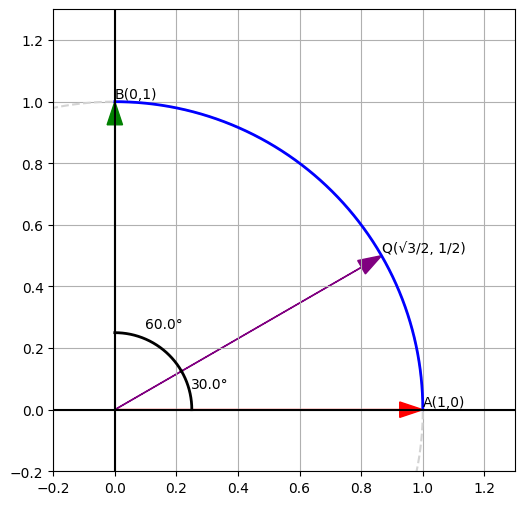

In [ ]:
from IPython.display import Image
Image('2.png')

### Answer:

The cosine similarity of two vectors is simply the cosine of the angle that these two vectors create with the origin.

Our query vector, $Q(\sqrt{3}/2, 1/2)$, creates an angle of 30 and 60 degrees with our indexed vectors respectively: $A(1, 0), B(0, 1)$.

Therefore: $$\cos_{sim}(Q, A) = \cos(30) = 0.866$$
$$\cos_{sim}(Q, B) = \cos(60) = 0.5$$

Since we chose to return the indexed vector with the highest cosine similarity, the **answer** is $A(1, 0)$ and its score is 0.866.



In [ ]:
result_point = hits.points[0]
print(f"Score: {result_point.score}")
print(f"Payload: {result_point.payload}")

Score: 0.8660254037844387
Payload: {'name': 'x_axis'}


##Filter search

We can apply filtering to our query, in order to narrow down the candidated indexed vectors when searching with a query.

By filtering, we basically search in a subset of indexed vectors, rather than the full collection.

In [ ]:
from pprint import pprint
from qdrant_client.models import Filter, FieldCondition

filtered_hits = client.query_points(
    collection_name="dummy_collection",
    query=query_vector,
    limit=2,
    query_filter=Filter(
        should=[
            # Narrow down points that have a name "y_axis"
            FieldCondition(key="name", match={"value": "y_axis"}),
        ]
    )
)

pprint(filtered_hits)
# We get 1 point, even though we have requested for 2 (why)?

QueryResponse(points=[ScoredPoint(id=1, version=0, score=0.5000000000000001, payload={'name': 'y_axis'}, vector=None, shard_key=None, order_value=None)])


# ****More realistic example****

We will now see how one can index vectors from embeddings, to retrieve most semantically similar texts to a query.

In [ ]:
from sentence_transformers import SentenceTransformer
encoder = SentenceTransformer('Alibaba-NLP/gte-multilingual-base', trust_remote_code=True) # Model to create embeddings

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/55.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Some weights of the model checkpoint at Alibaba-NLP/gte-multilingual-base were not used when initializing NewModel: ['classifier.bias', 'classifier.weight']
- This IS expected if you are initializing NewModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing NewModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
documents = [
  { "name": "The Time Machine", "description": "A man travels through time and witnesses the evolution of humanity.", "author": "H.G. Wells", "year": 1895 },
  { "name": "The Invisible Man", "description": "A scientist discovers a way to make himself invisible but struggles to control his power.", "author": "H.G. Wells", "year": 1897 },
  { "name": "Ender's Game", "description": "A young boy is trained to become a military leader in a war against an alien race.", "author": "Orson Scott Card", "year": 1985 },
  { "name": "Brave New World", "description": "A dystopian society where people are genetically engineered and conditioned to conform to a strict social hierarchy.", "author": "Aldous Huxley", "year": 1932 },
  { "name": "The Hitchhiker's Guide to the Galaxy", "description": "A comedic science fiction series following the misadventures of an unwitting human and his alien friend.", "author": "Douglas Adams", "year": 1979 },
  { "name": "Dune", "description": "A desert planet is the site of political intrigue and power struggles.", "author": "Frank Herbert", "year": 1965 },
  { "name": "Foundation", "description": "A mathematician develops a science to predict the future of humanity and works to save civilization from collapse.", "author": "Isaac Asimov", "year": 1951 },
  { "name": "I, Robot", "description": "A collection of short stories exploring the ethical implications of robotics and artificial intelligence.", "author": "Isaac Asimov", "year": 1950 },
  { "name": "Snow Crash", "description": "A futuristic world where the internet has evolved into a virtual reality metaverse.", "author": "Neal Stephenson", "year": 1992 },
  { "name": "Neuromancer", "description": "A hacker is hired to pull off a near-impossible hack and gets pulled into a web of intrigue.", "author": "William Gibson", "year": 1984 },
  { "name": "The War of the Worlds", "description": "A Martian invasion of Earth throws humanity into chaos.", "author": "H.G. Wells", "year": 1898 },
  { "name": "The Hunger Games", "description": "A dystopian society where teenagers are forced to fight to the death in a televised spectacle.", "author": "Suzanne Collins", "year": 2008 },
  { "name": "The Andromeda Strain", "description": "A deadly virus from outer space threatens to wipe out humanity.", "author": "Michael Crichton", "year": 1969 },
  { "name": "The Left Hand of Darkness", "description": "A human ambassador is sent to a planet where the inhabitants are genderless and can change gender at will.", "author": "Ursula K. Le Guin", "year": 1969 },
  { "name": "The Dispossessed", "description": "An anarchist utopia on a barren moon contrasts with a capitalist society on a fertile planet.", "author": "Ursula K. Le Guin", "year": 1974 },
  { "name": "The Time Traveler's Wife", "description": "A love story between a man who involuntarily time travels and the woman he loves.", "author": "Audrey Niffenegger", "year": 2003 }
]

In [ ]:
from qdrant_client.models import Distance, VectorParams

client.create_collection(
    collection_name="book_collection",
    vectors_config=VectorParams(size=768, distance=Distance.COSINE),
)

True

In [ ]:
from qdrant_client.models import PointStruct

# NOTE: For demo reasons, we encode one description at a time. For real-world
# applications we would prefer batch encoding.
client.upsert(
    collection_name="book_collection",
    points=[
        PointStruct(
            id=idx,
            vector=encoder.encode(doc["description"], normalize_embeddings=True).tolist(),
            payload=doc
        )
        for idx, doc in enumerate(documents)
    ]
)

UpdateResult(operation_id=0, status=<UpdateStatus.COMPLETED: 'completed'>)

##Vanilla vector search

In [ ]:
query = "mathematician resques humanity"
query_vector = encoder.encode(query, normalize_embeddings=True)

book_hits = client.query_points(
    collection_name="book_collection",
    query=query_vector.tolist(),
    limit=3
)
book_hits

QueryResponse(points=[ScoredPoint(id=6, version=0, score=0.7989064461481952, payload={'name': 'Foundation', 'description': 'A mathematician develops a science to predict the future of humanity and works to save civilization from collapse.', 'author': 'Isaac Asimov', 'year': 1951}, vector=None, shard_key=None, order_value=None), ScoredPoint(id=0, version=0, score=0.6176339838633051, payload={'name': 'The Time Machine', 'description': 'A man travels through time and witnesses the evolution of humanity.', 'author': 'H.G. Wells', 'year': 1895}, vector=None, shard_key=None, order_value=None), ScoredPoint(id=13, version=0, score=0.6061359023924169, payload={'name': 'The Left Hand of Darkness', 'description': 'A human ambassador is sent to a planet where the inhabitants are genderless and can change gender at will.', 'author': 'Ursula K. Le Guin', 'year': 1969}, vector=None, shard_key=None, order_value=None)])

In [ ]:
from pprint import pprint

print(f"Query: {query}")
print("The most similar matches found to our query within our vector index are:\n\n")
for point in book_hits.points:
  print(f"Score: {point.score}")
  pprint(point.payload)
  print("\n")

Query: mathematician resques humanity
The most similar matches found to our query within our vector index are:


Score: 0.7989064461481952
{'author': 'Isaac Asimov',
 'description': 'A mathematician develops a science to predict the future of '
                'humanity and works to save civilization from collapse.',
 'name': 'Foundation',
 'year': 1951}


Score: 0.6176339838633051
{'author': 'H.G. Wells',
 'description': 'A man travels through time and witnesses the evolution of '
                'humanity.',
 'name': 'The Time Machine',
 'year': 1895}


Score: 0.6061359023924169
{'author': 'Ursula K. Le Guin',
 'description': 'A human ambassador is sent to a planet where the inhabitants '
                'are genderless and can change gender at will.',
 'name': 'The Left Hand of Darkness',
 'year': 1969}




###Filter based on year

In [ ]:
from qdrant_client.models import Filter, FieldCondition, Range

filtered_book_hits = client.query_points(
    collection_name="book_collection",
    query=query_vector,
    query_filter=Filter(
        must=[
            FieldCondition(
                key="year",
                range=Range(
                    gte=1952
                )
            )
        ]
    ),
    limit=3
)

In [ ]:
for point in filtered_book_hits.points:
  print(f"Score: {point.score}")
  pprint(point.payload)
  print("\n")

Score: 0.6061359023924169
{'author': 'Ursula K. Le Guin',
 'description': 'A human ambassador is sent to a planet where the inhabitants '
                'are genderless and can change gender at will.',
 'name': 'The Left Hand of Darkness',
 'year': 1969}


Score: 0.558660965169411
{'author': 'Ursula K. Le Guin',
 'description': 'An anarchist utopia on a barren moon contrasts with a '
                'capitalist society on a fertile planet.',
 'name': 'The Dispossessed',
 'year': 1974}


Score: 0.5486793132765698
{'author': 'William Gibson',
 'description': 'A hacker is hired to pull off a near-impossible hack and gets '
                'pulled into a web of intrigue.',
 'name': 'Neuromancer',
 'year': 1984}




We have narrowed down the results too much: The highest score is 0.60, which (at least for this specific embbedding model) does not signify high semantic similarity.

##Keyword search

We can return points that include a string in a text field in their payload. You can read more about Qdrant's full-text search capabilities [here](https://qdrant.tech/articles/qdrant-introduces-full-text-filters-and-indexes/), in order to use more advanced techniques like stemming etc.

In [ ]:
from qdrant_client.models import Filter, FieldCondition, MatchText

query = "dystopian"

results = client.scroll(
    collection_name="book_collection",
    scroll_filter=Filter(
        must=[
            FieldCondition(
                key="description",
                match=MatchText(text=query)
            )
        ]
    ),
    limit=5
)

results

([Record(id=3, payload={'name': 'Brave New World', 'description': 'A dystopian society where people are genetically engineered and conditioned to conform to a strict social hierarchy.', 'author': 'Aldous Huxley', 'year': 1932}, vector=None, shard_key=None, order_value=None),
  Record(id=11, payload={'name': 'The Hunger Games', 'description': 'A dystopian society where teenagers are forced to fight to the death in a televised spectacle.', 'author': 'Suzanne Collins', 'year': 2008}, vector=None, shard_key=None, order_value=None)],
 None)

In [ ]:
for record in results[0]:
  pprint(record.payload)
  print("\n")

{'author': 'Aldous Huxley',
 'description': 'A dystopian society where people are genetically engineered '
                'and conditioned to conform to a strict social hierarchy.',
 'name': 'Brave New World',
 'year': 1932}


{'author': 'Suzanne Collins',
 'description': 'A dystopian society where teenagers are forced to fight to '
                'the death in a televised spectacle.',
 'name': 'The Hunger Games',
 'year': 2008}




## Combine vector search with keyword search

In [ ]:
query_vector = encoder.encode("dangerous conflict", normalize_embeddings=True)

filtered_book_hits = client.query_points(
    collection_name="book_collection",
    query=query_vector,
    query_filter=Filter(
        must=[
            FieldCondition(
                key="year",
                range=Range(
                    gte=1573
                )
            ),
            FieldCondition(
                key="description",
                match=MatchText(text="dystopian")
            )
        ]
    ),
    limit=3
)

In [ ]:
for point in filtered_book_hits.points:
  print(f"Score: {point.score}")
  pprint(point.payload)
  print("\n")

Score: 0.5905521830447508
{'author': 'Suzanne Collins',
 'description': 'A dystopian society where teenagers are forced to fight to '
                'the death in a televised spectacle.',
 'name': 'The Hunger Games',
 'year': 2008}


Score: 0.4836255372261996
{'author': 'Aldous Huxley',
 'description': 'A dystopian society where people are genetically engineered '
                'and conditioned to conform to a strict social hierarchy.',
 'name': 'Brave New World',
 'year': 1932}




Points returned:
- Their description includes the string "dystopian"
- Their year is greater than or equal to 1573
- Are ranked based on our query: "dangerous conflict". As expected, the embedding that represents the description of "The Hunger Games has a higher score than that of "Brave New World" (because of the sequence "fight to death" in its description), but its score is still low, because of the other information its embebdding represents.

# ****In class exercise: Create your own collection and query it!****